# CNM Analysis for p+Pb LHC (5.02 & 8.16 TeV)
This notebook calculates and plots the coherent nuclear matter (CNM) effects (nPDF shadowing, coherent energy loss, and Cronin broadening) for charmonia in p+Pb collisions at LHC energies.

**Components:**
- **nPDF**: Shadowing using EPPS21
- **ELoss**: Coherent energy loss (Arleo-Peigné)
- **Broad**: Cronin pT broadening
- **ELoss + Broad**: Product of ELoss and Broadening factors
- **Total CNM**: nPDF × (ELoss × Broad)

**Styling**: Publication-ready plots with consistent color schemes.

## Setup & Calc

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dataclasses import replace

# Add paths for custom modules
sys.path.append('..')
sys.path.append('../eloss_code')
sys.path.append('../cnm_combine')
sys.path.append('../npdf_code')

from cnm_combine_fast import CNMCombineFast
from particle import Particle
from system_configs import LHCConfig as Config

import warnings
warnings.filterwarnings('ignore')

# Constants and Knobs
SAVE_PDF = True
SAVE_CSV = True
DPI = 150
ALPHA_BAND = 0.25
STEP_DEFAULT = True

# Color Scheme
COLORS = {
    'npdf': '#E69F00',
    'eloss': "#EC5B5B",
    'broad': "#2B2BEF",
    'eloss_broad': "#020202", # Product of loss and broad
    'cnm': 'gray'
}

COMP_LABELS = {
    'npdf': 'nPDF (EPPS21)',
    'eloss': 'Energy Loss',
    'broad': r'$p_T$ Broadening',
    'eloss_broad': r'ELoss + $p_T$ Broad',
    'cnm': 'Total CNM'
}

print("Setup complete.")

Setup complete.


In [2]:
def step_from_centers(xc, yc):
    """Construct edges for ax.step(where='post') from centers"""
    xc = np.asarray(xc, float)
    yc = np.asarray(yc, float)
    if xc.size < 2:
        dx = 1.0
        return np.array([xc[0]-0.5*dx, xc[0]+0.5*dx], float), np.array([yc[0], yc[0]], float)
    
    # Assuming equal spacing for convenience in finding edges
    dx = xc[1] - xc[0] 
    edges = np.concatenate([xc - 0.5*dx, [xc[-1] + 0.5*dx]])
    vals = np.concatenate([yc, [yc[-1]]])
    return edges, vals

def apply_pub_style(ax, xlim, ylim, xlabel, ylabel, tag=None, note=None):
    """Standardize plot appearance"""
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.axhline(1.0, color='k', ls='-', lw=0.8, alpha=0.5)
    
    ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=10)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    
    if tag:
        ax.text(0.95, 0.95, tag, transform=ax.transAxes, ha='right', va='top', 
                fontsize=12, fontweight='bold')
    if note:
        ax.text(0.05, 0.05, note, transform=ax.transAxes, ha='left', va='bottom', 
                fontsize=10, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

def plot_component_band(ax, x_cent, bands, comp, tag, step=True, **kwargs):
    """Plot a single component band"""
    Rc_dict, Rlo_dict, Rhi_dict = bands[comp]
    xc = np.asarray(x_cent)
    yc = np.asarray(Rc_dict[tag])
    yl = np.asarray(Rlo_dict[tag])
    yh = np.asarray(Rhi_dict[tag])
    
    color = COLORS.get(comp, 'black')
    label = COMP_LABELS.get(comp, comp)
    
    if step:
        xe, ye = step_from_centers(xc, yc)
        _, yel = step_from_centers(xc, yl)
        _, yeh = step_from_centers(xc, yh)
        ax.step(xe, ye, where='post', color=color, lw=1.8, label=label)
        ax.fill_between(xe, yel, yeh, step='post', color=color, alpha=ALPHA_BAND, lw=0)
    else:
        ax.plot(xc, yc, color=color, lw=1.8, label=label)
        ax.fill_between(xc, yl, yh, color=color, alpha=ALPHA_BAND, lw=0)

In [4]:
## Compute For later plotting
energies = [5.02, 8.16]
components = ['npdf', 'eloss', 'broad', 'eloss_broad', 'cnm']

# --- caches keyed by energy ---
cnm_by_E   = {}
outdir_by_E = {}

# results caches
res_y   = {}   # E -> (y_cent, labels, final_bands_y, y_edges)
res_pt  = {}   # E -> dict[y_window] -> (pT_cent, labels_pt, final_bands_pt, pT_edges)
res_cent = {}  # E -> dict[y_window] -> res_cent_dict

In [5]:
for energy in energies:
    print(f"\n[LOAD] {energy} TeV ...")
    outdir = Path(f'../outputs/LHC_{energy}TeV')
    outdir.mkdir(parents=True, exist_ok=True)
    outdir_by_E[energy] = outdir

    particle = Particle(family='charmonia', state='avg')
    cnm = CNMCombineFast.from_defaults(
        energy=str(energy),
        family='charmonia',
        particle_state='avg',
        alpha_s_mode='constant',
        alpha0=0.5,
        cent_bins=Config.cent_bins_plotting
    )
    cnm_by_E[energy] = cnm
    print("Loading and calc done.")


[LOAD] 5.02 TeV ...
Loading and calc done.

[LOAD] 8.16 TeV ...
Loading and calc done.


## Production Loop over Energies


Processing 5.02 TeV...


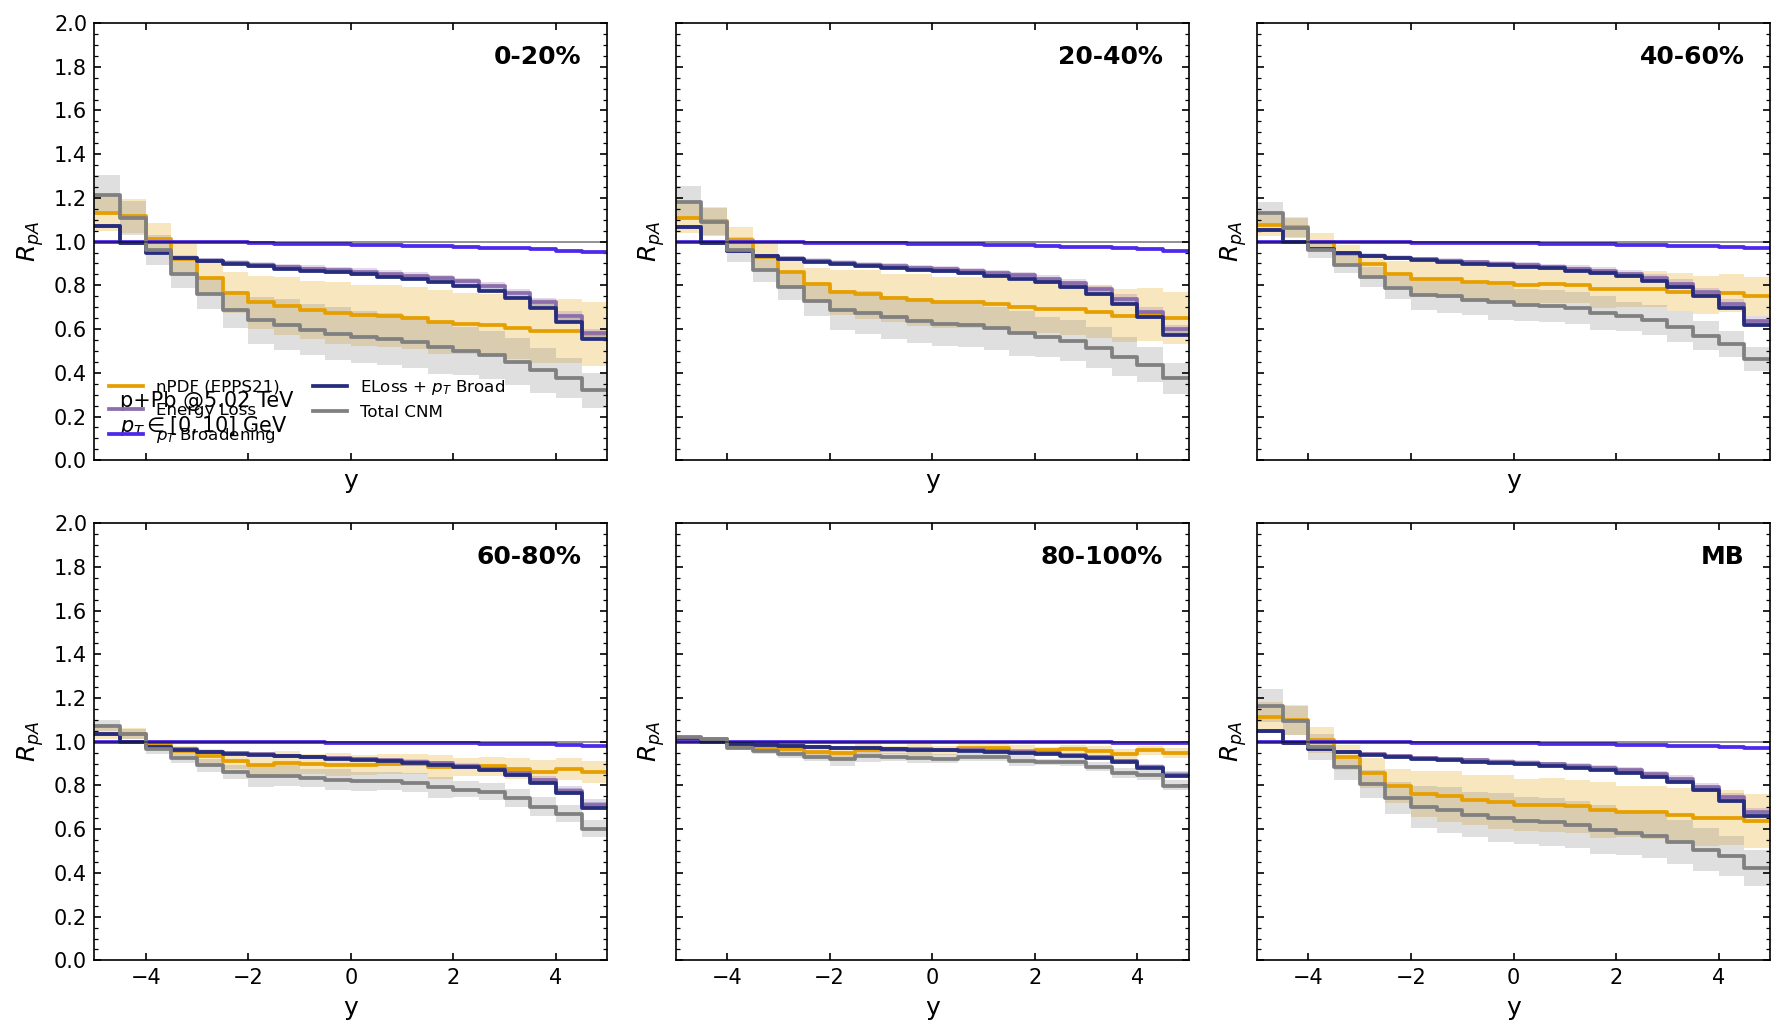

  Computing vs pT in window -4.46<y<-2.96


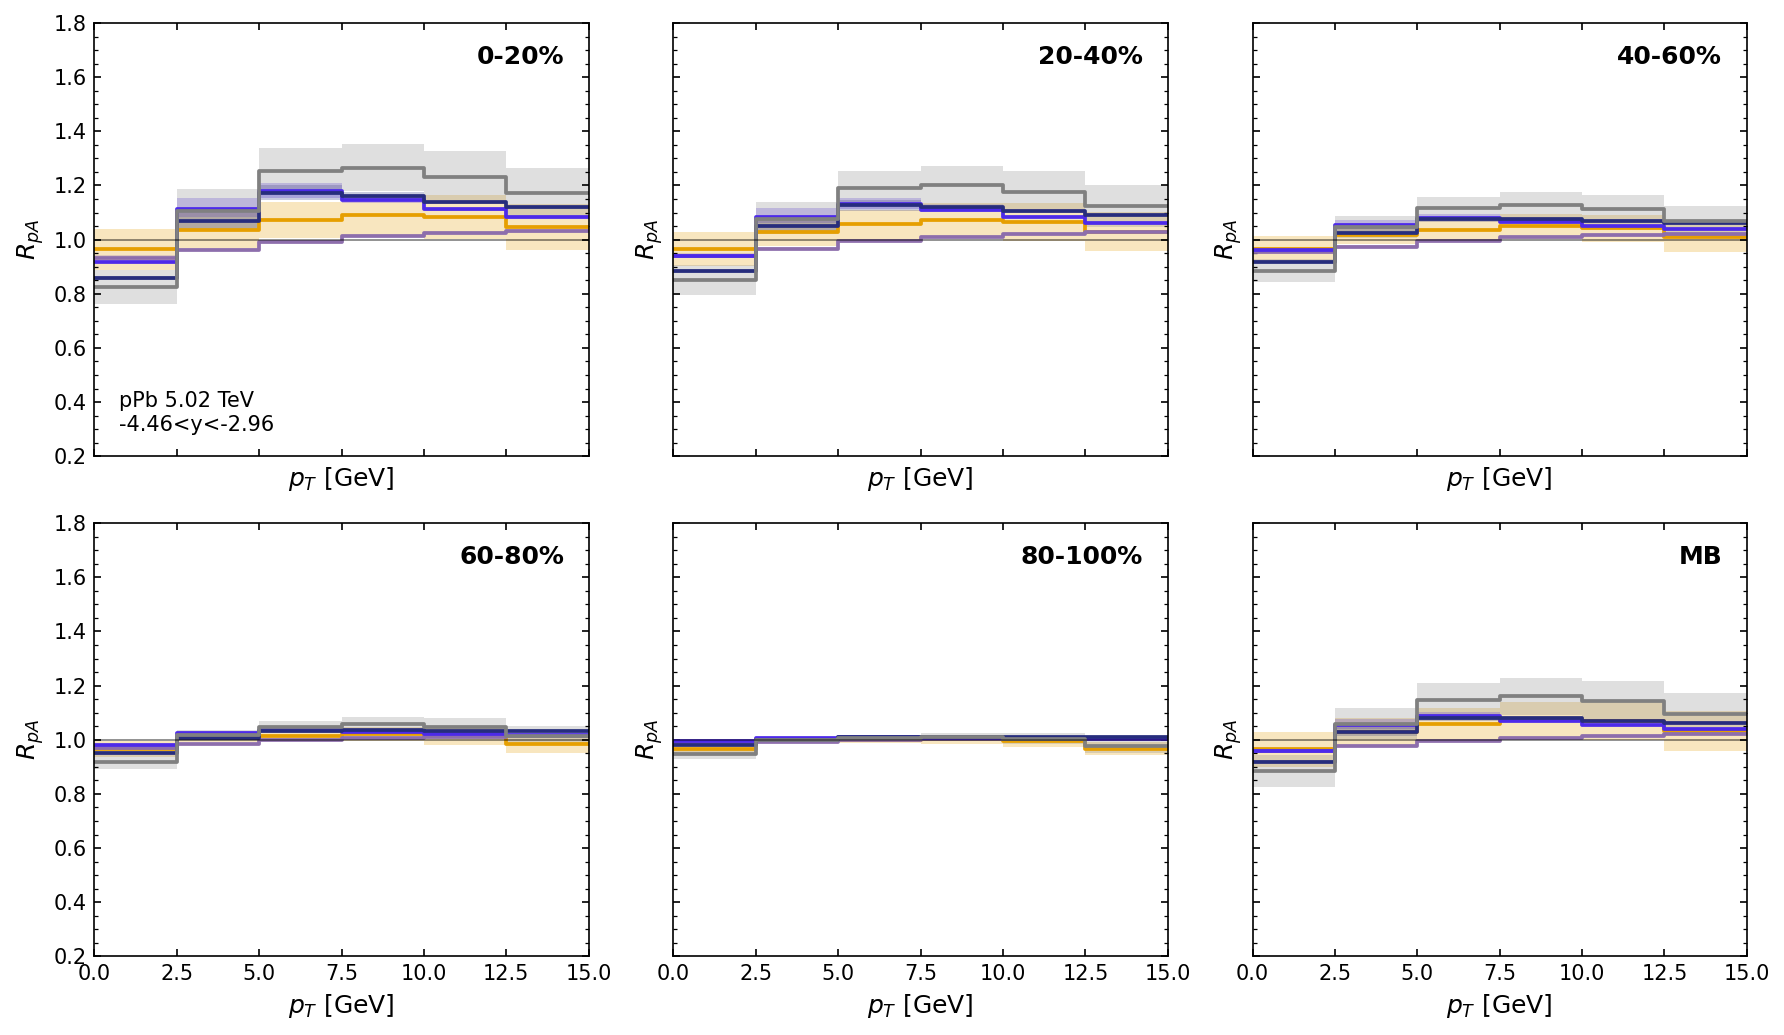

  Computing vs pT in window -1.37<y<0.43


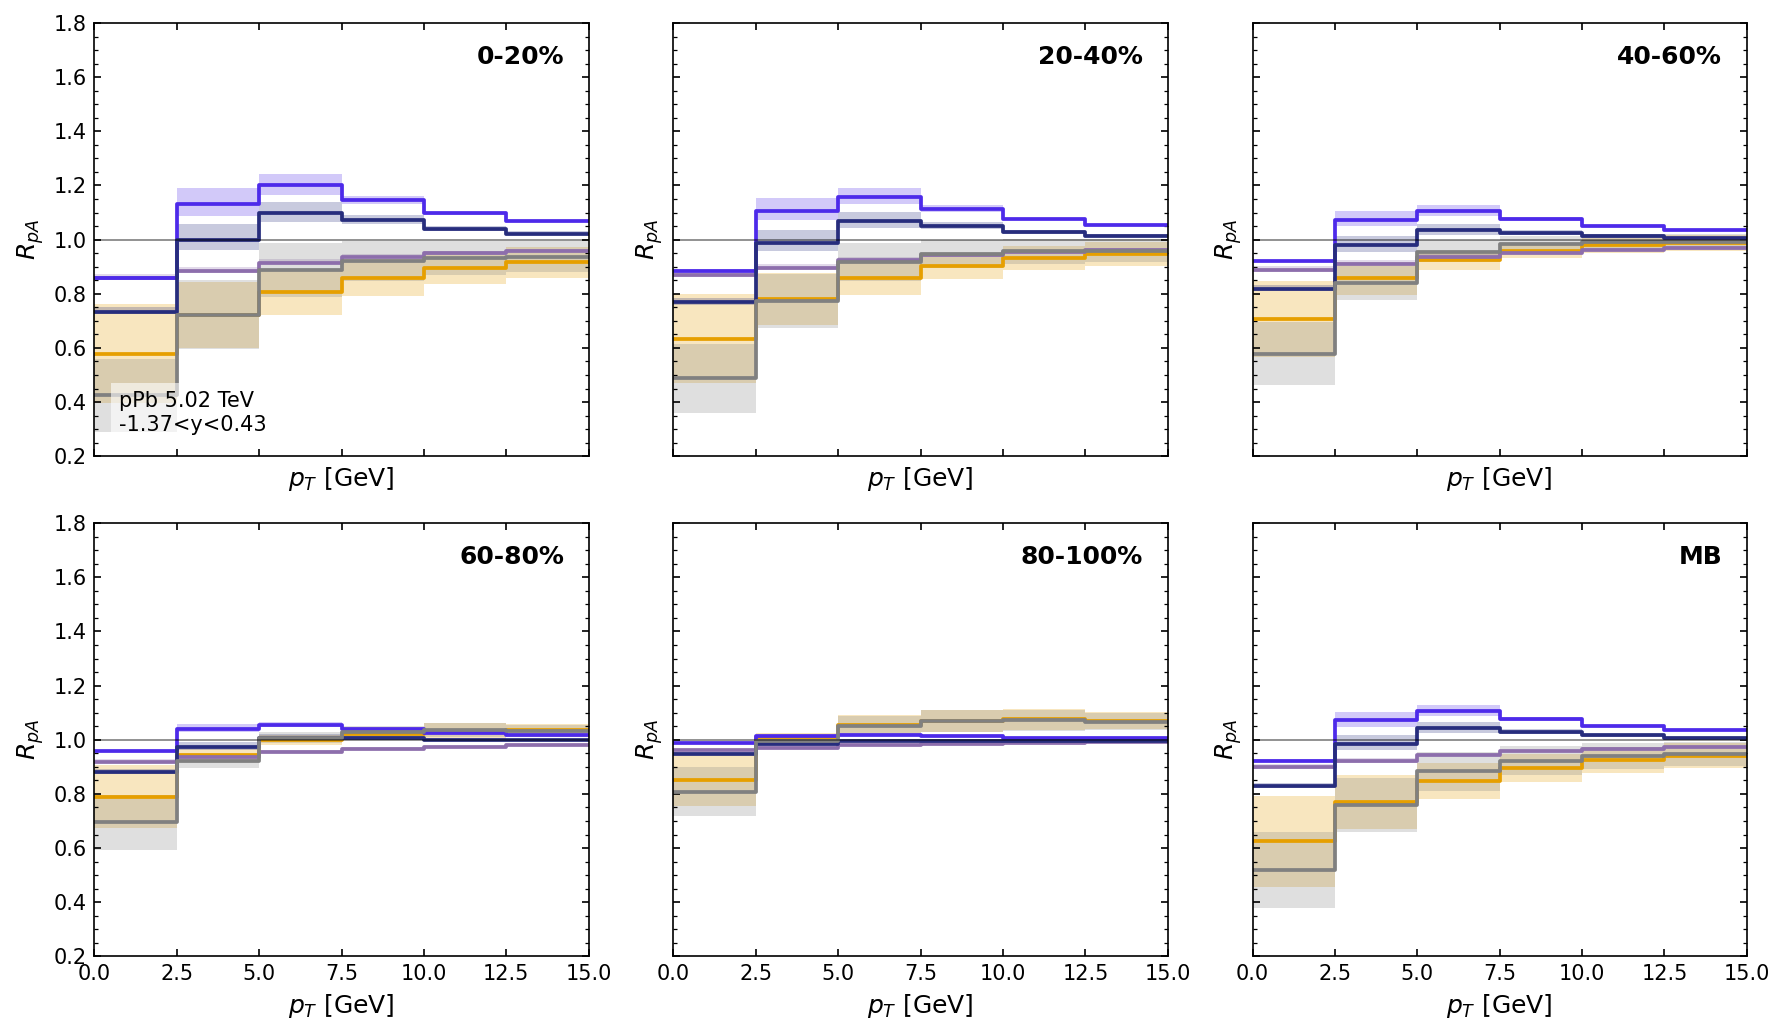

  Computing vs pT in window 2.03<y<3.53


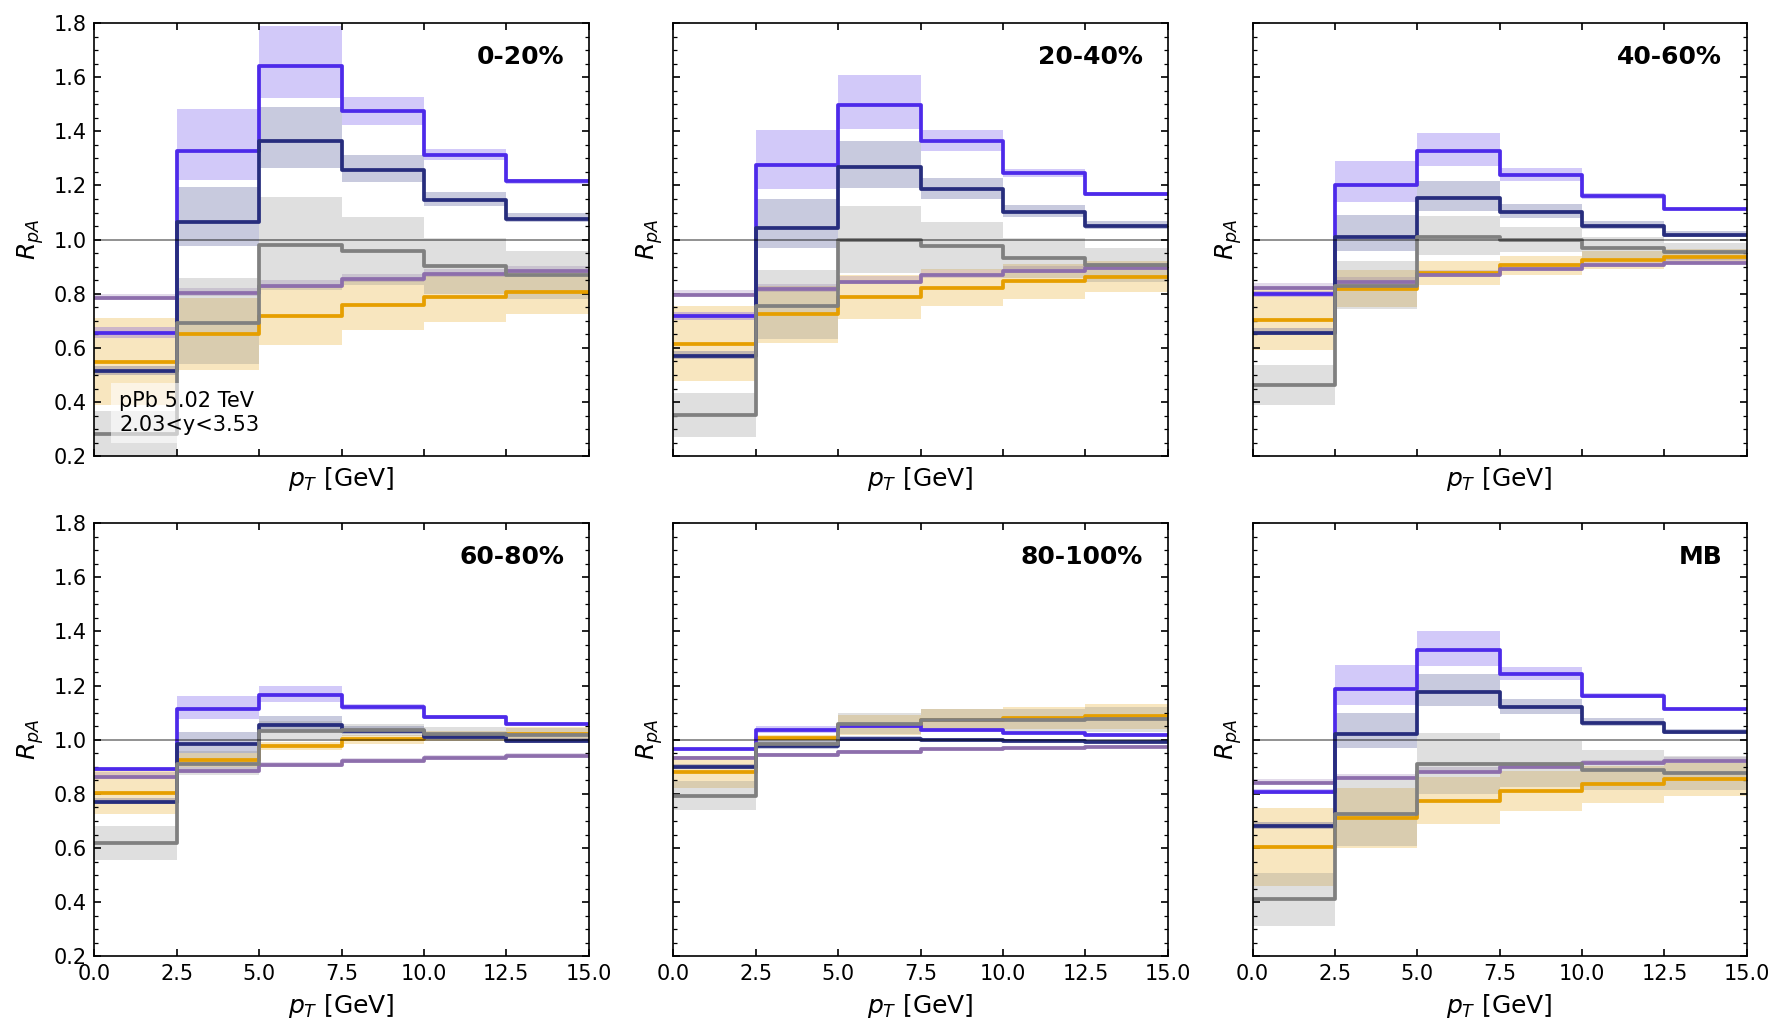

  Computing vs Centrality...


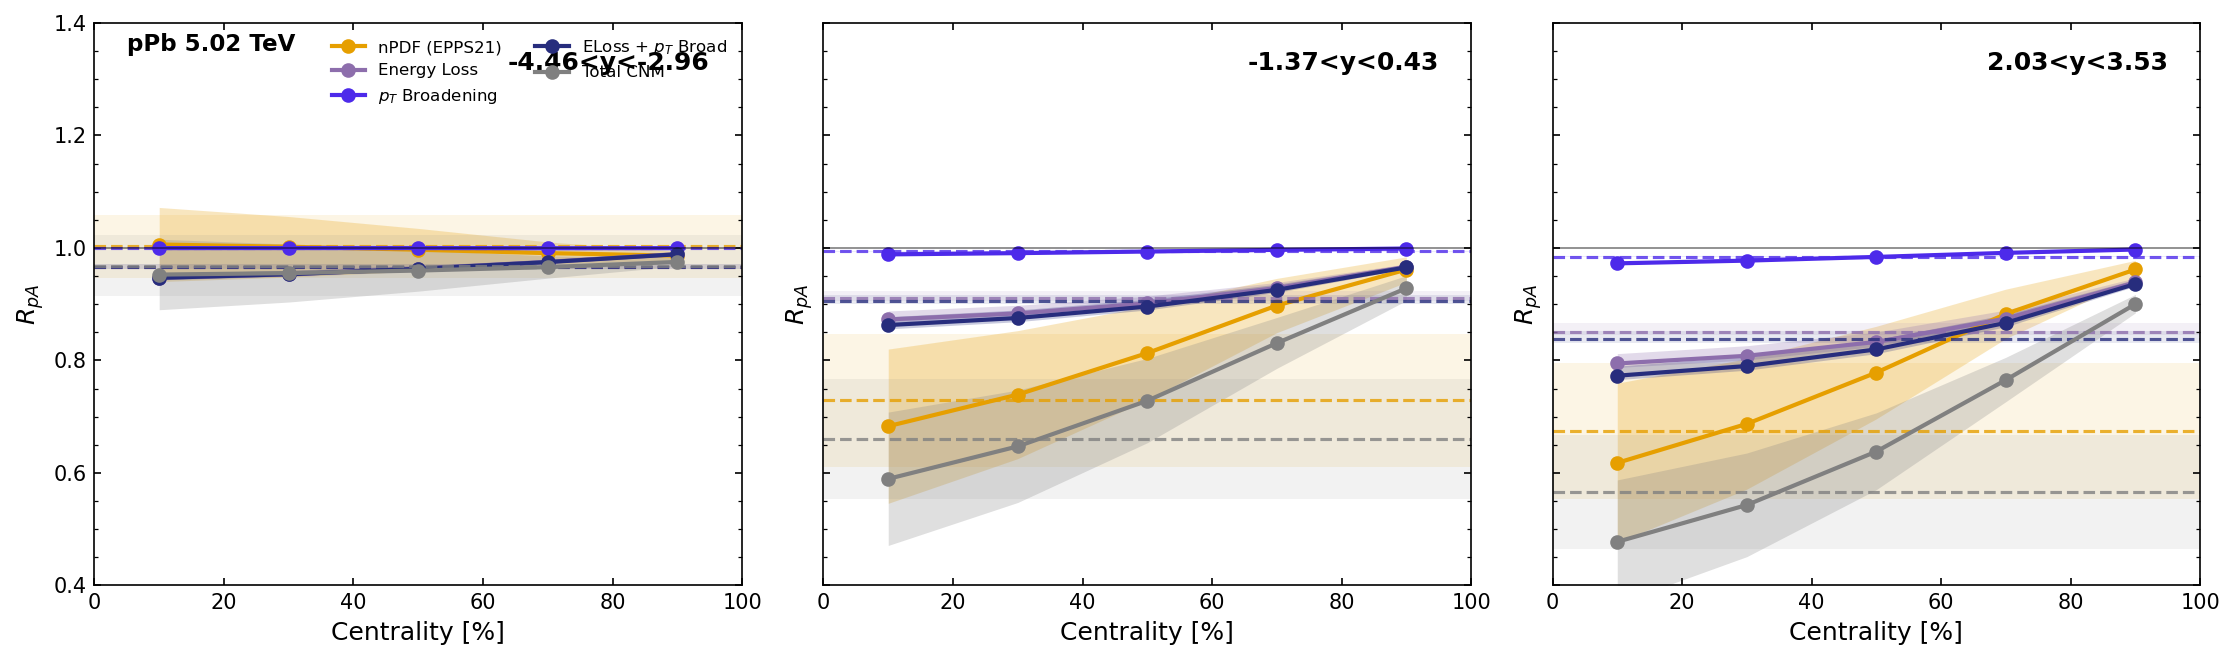


Processing 8.16 TeV...


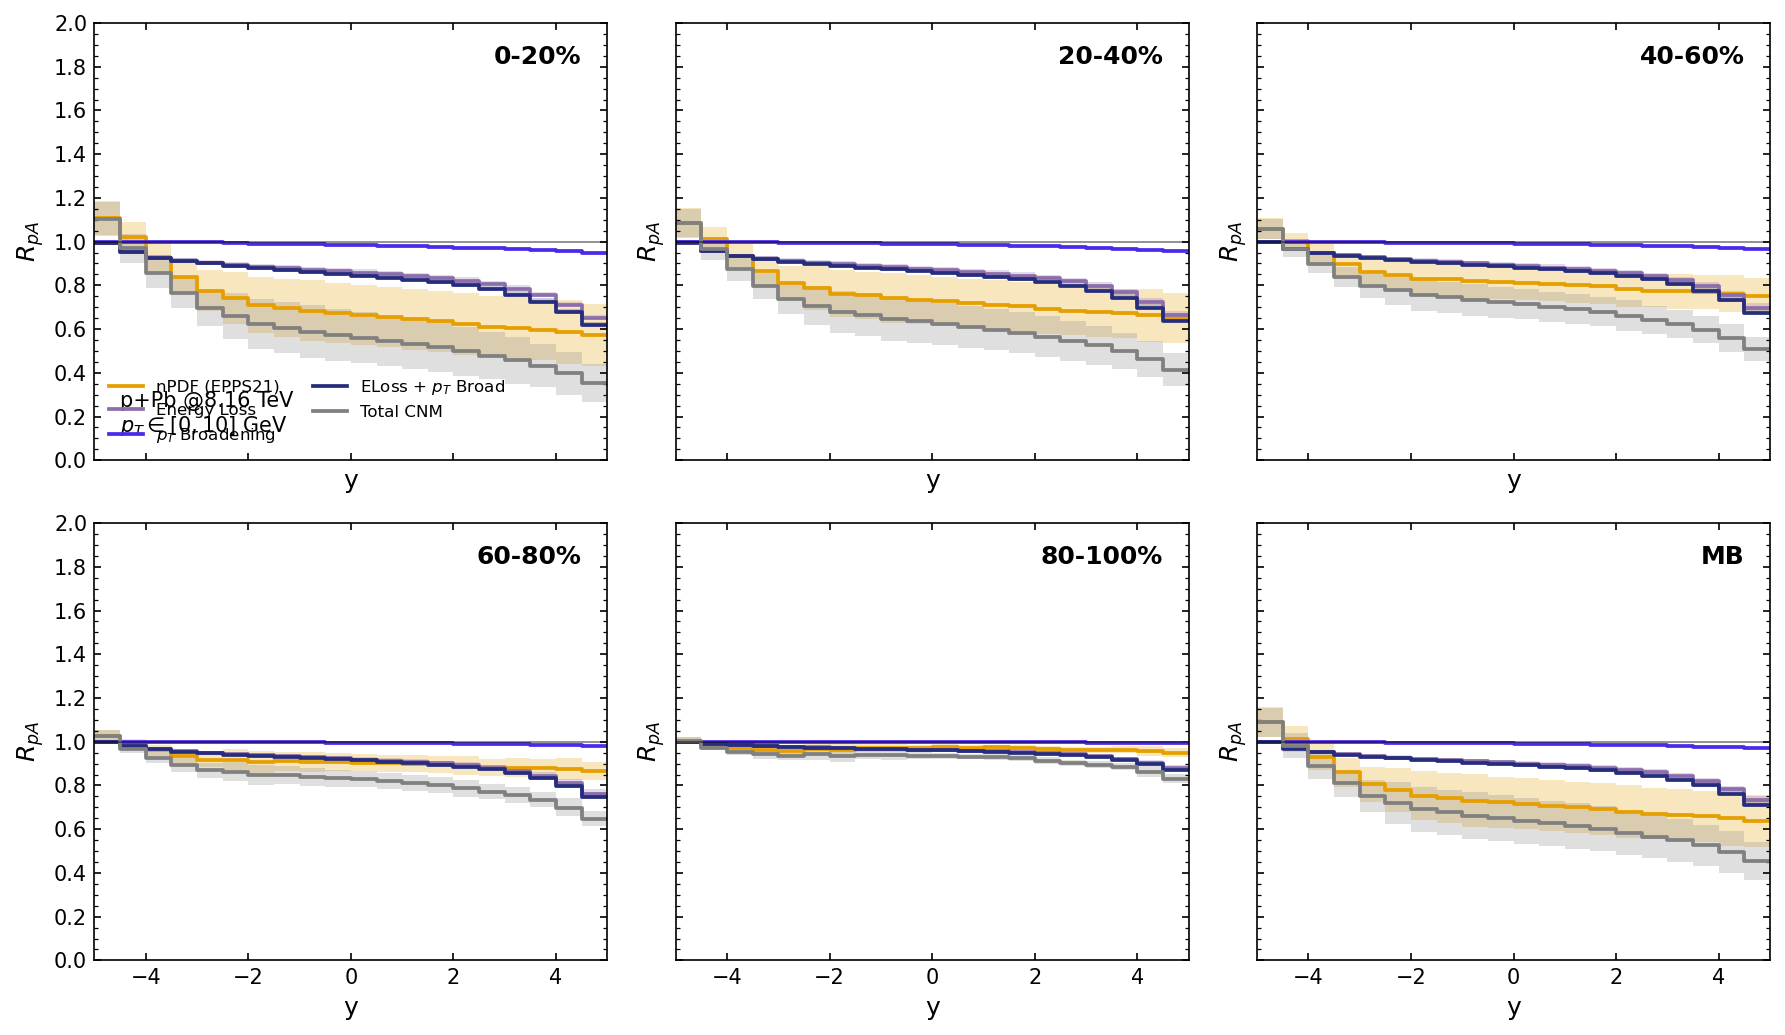

  Computing vs pT in window -4.46<y<-2.96


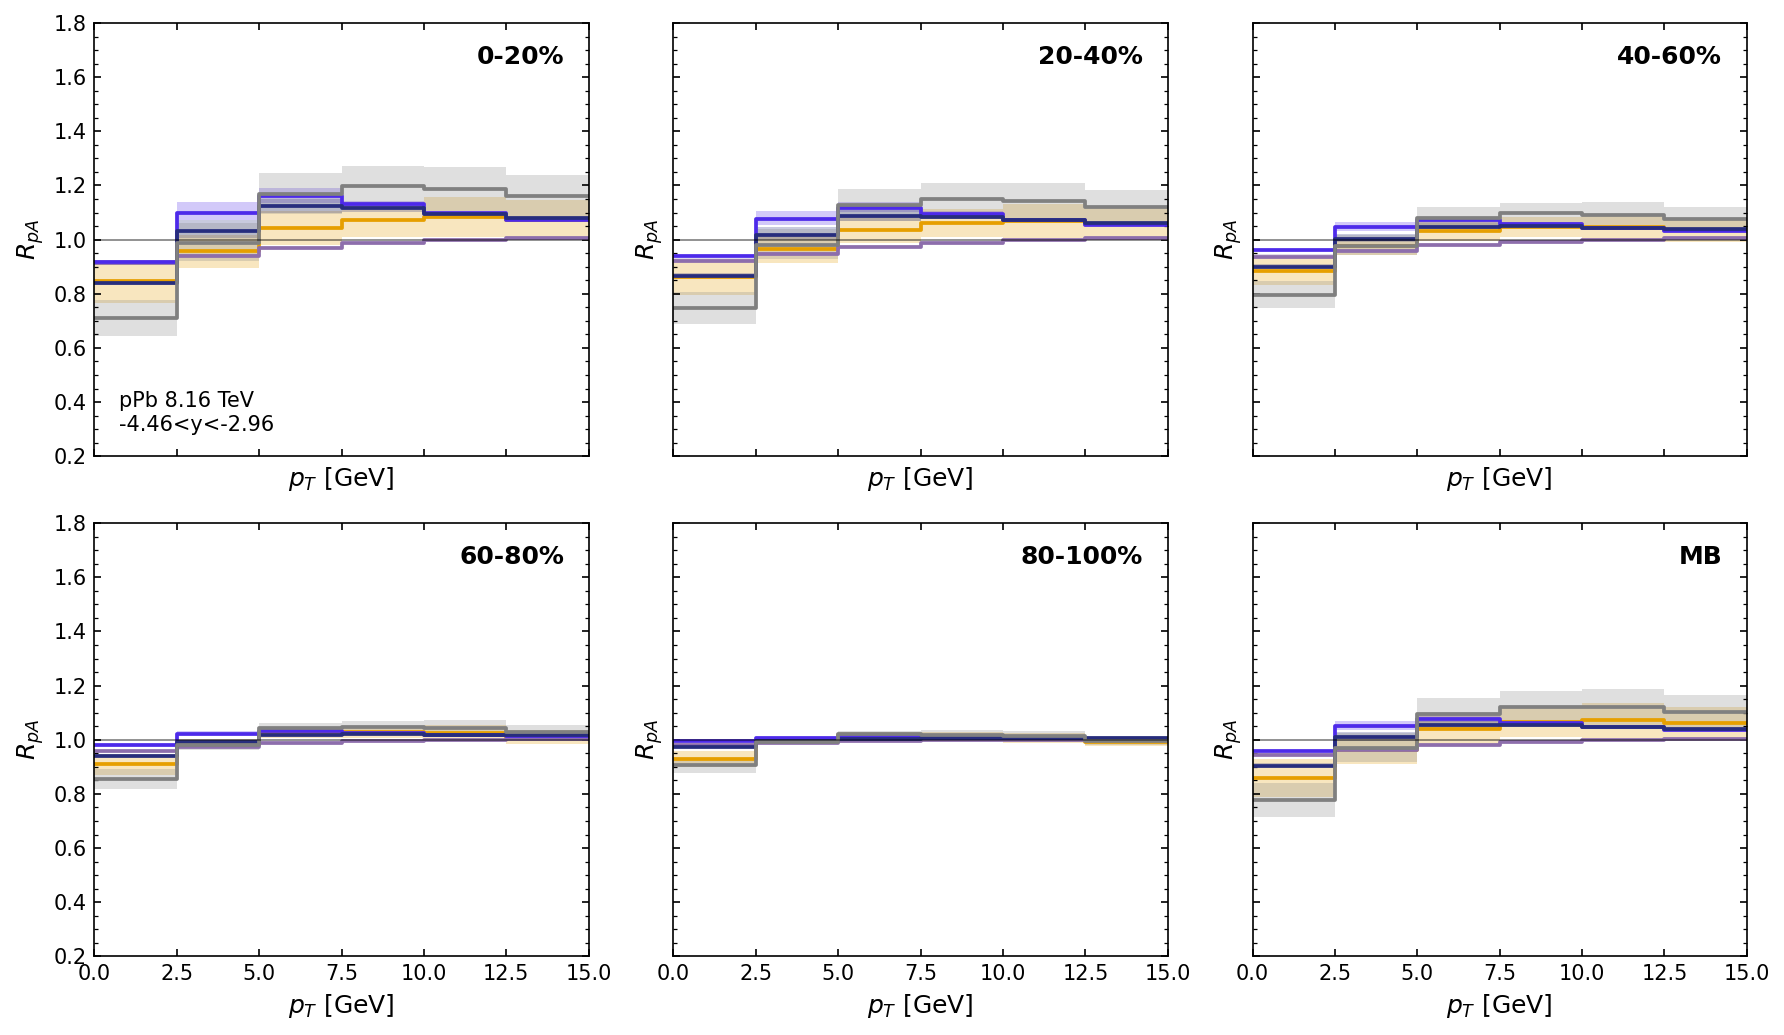

  Computing vs pT in window -1.37<y<0.43


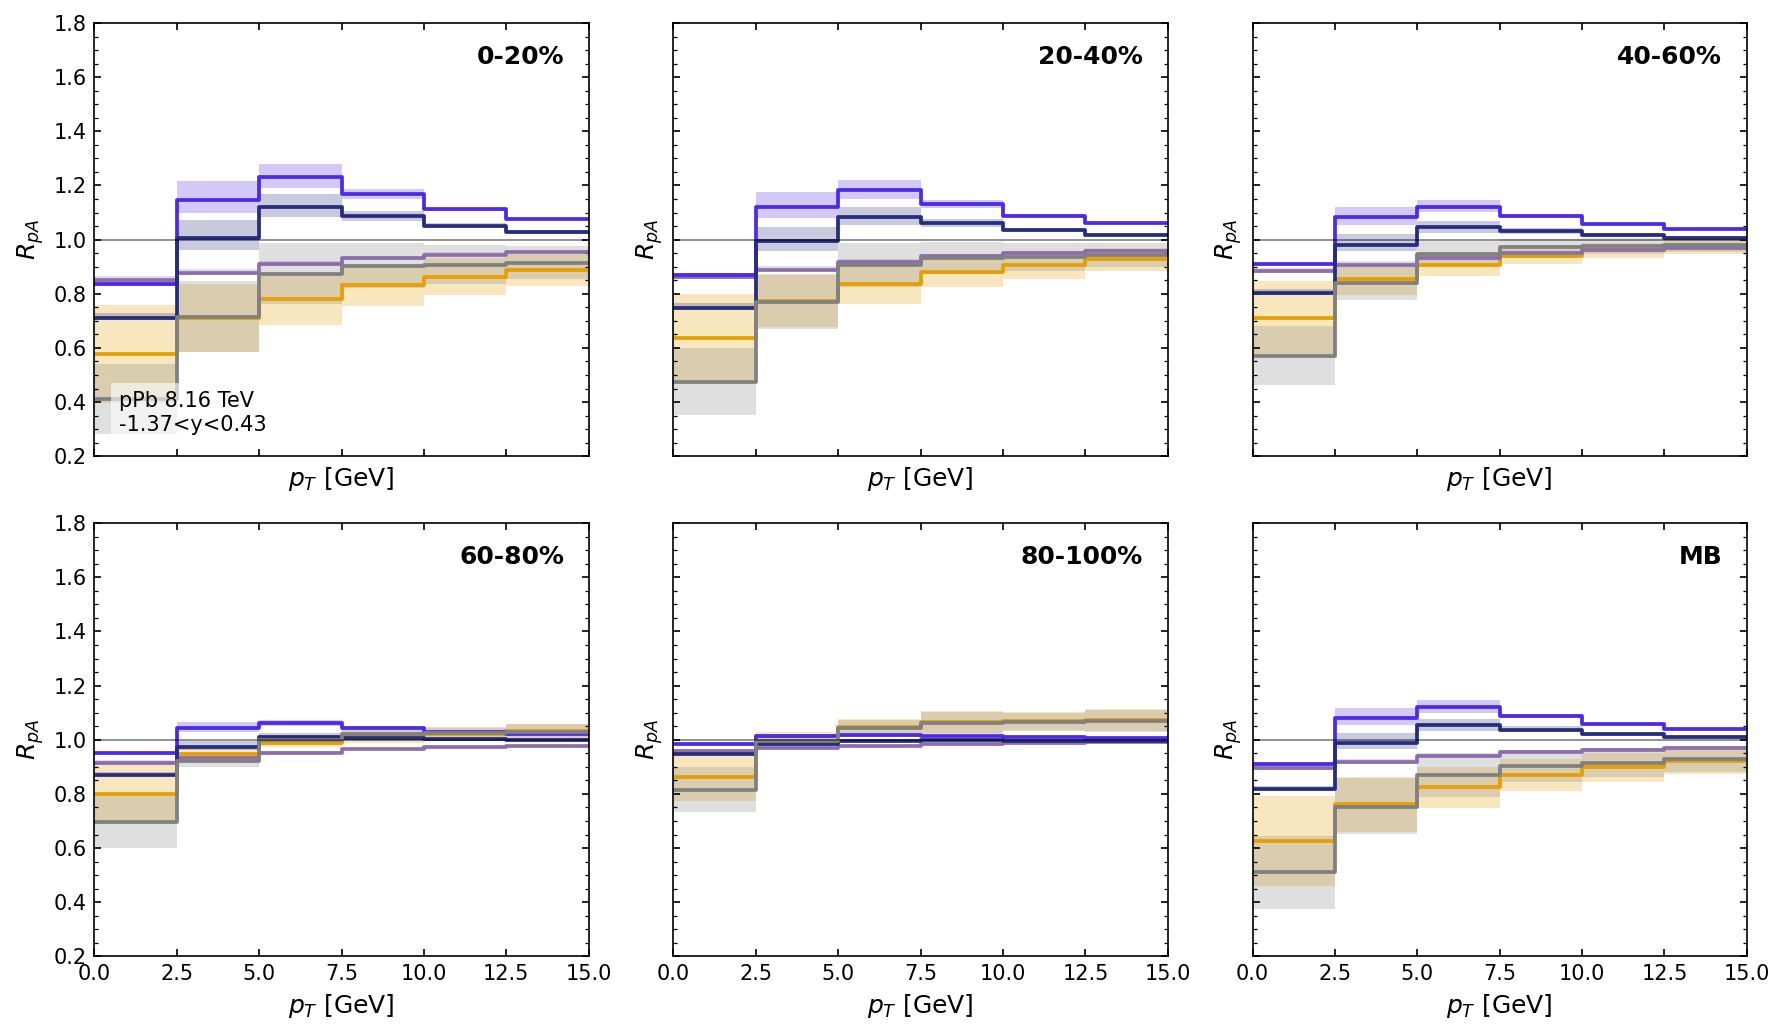

  Computing vs pT in window 2.03<y<3.53


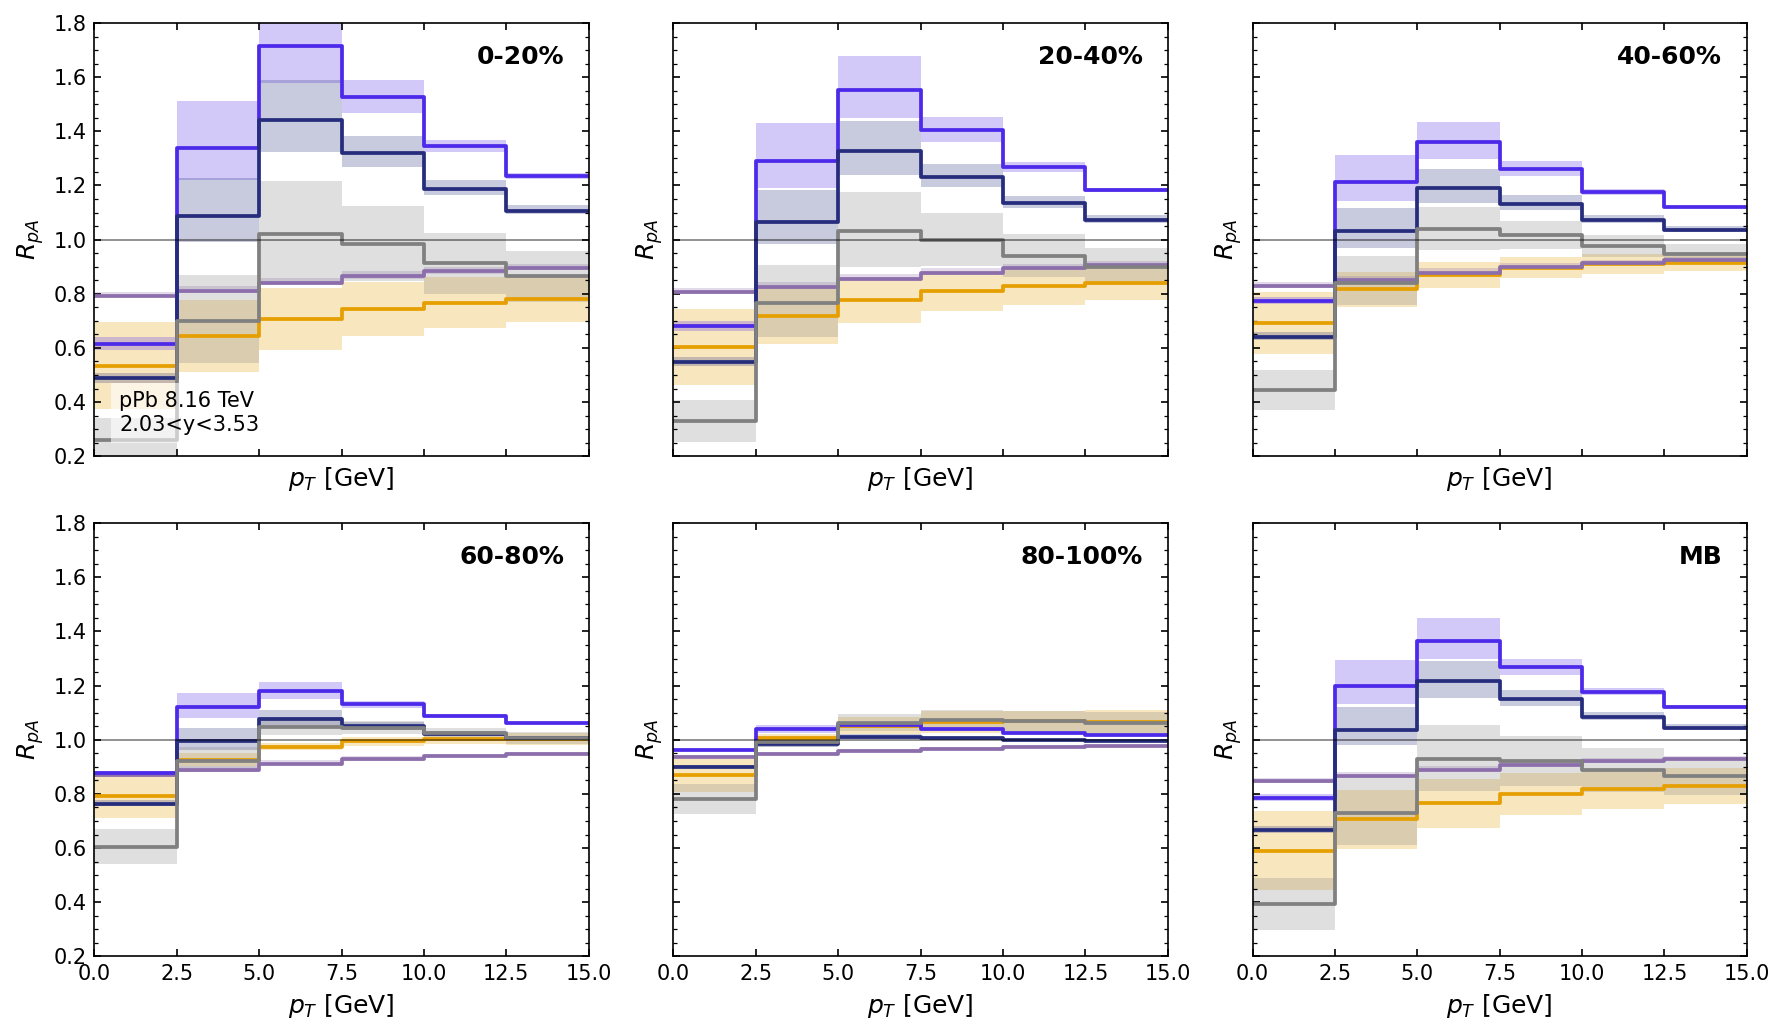

  Computing vs Centrality...


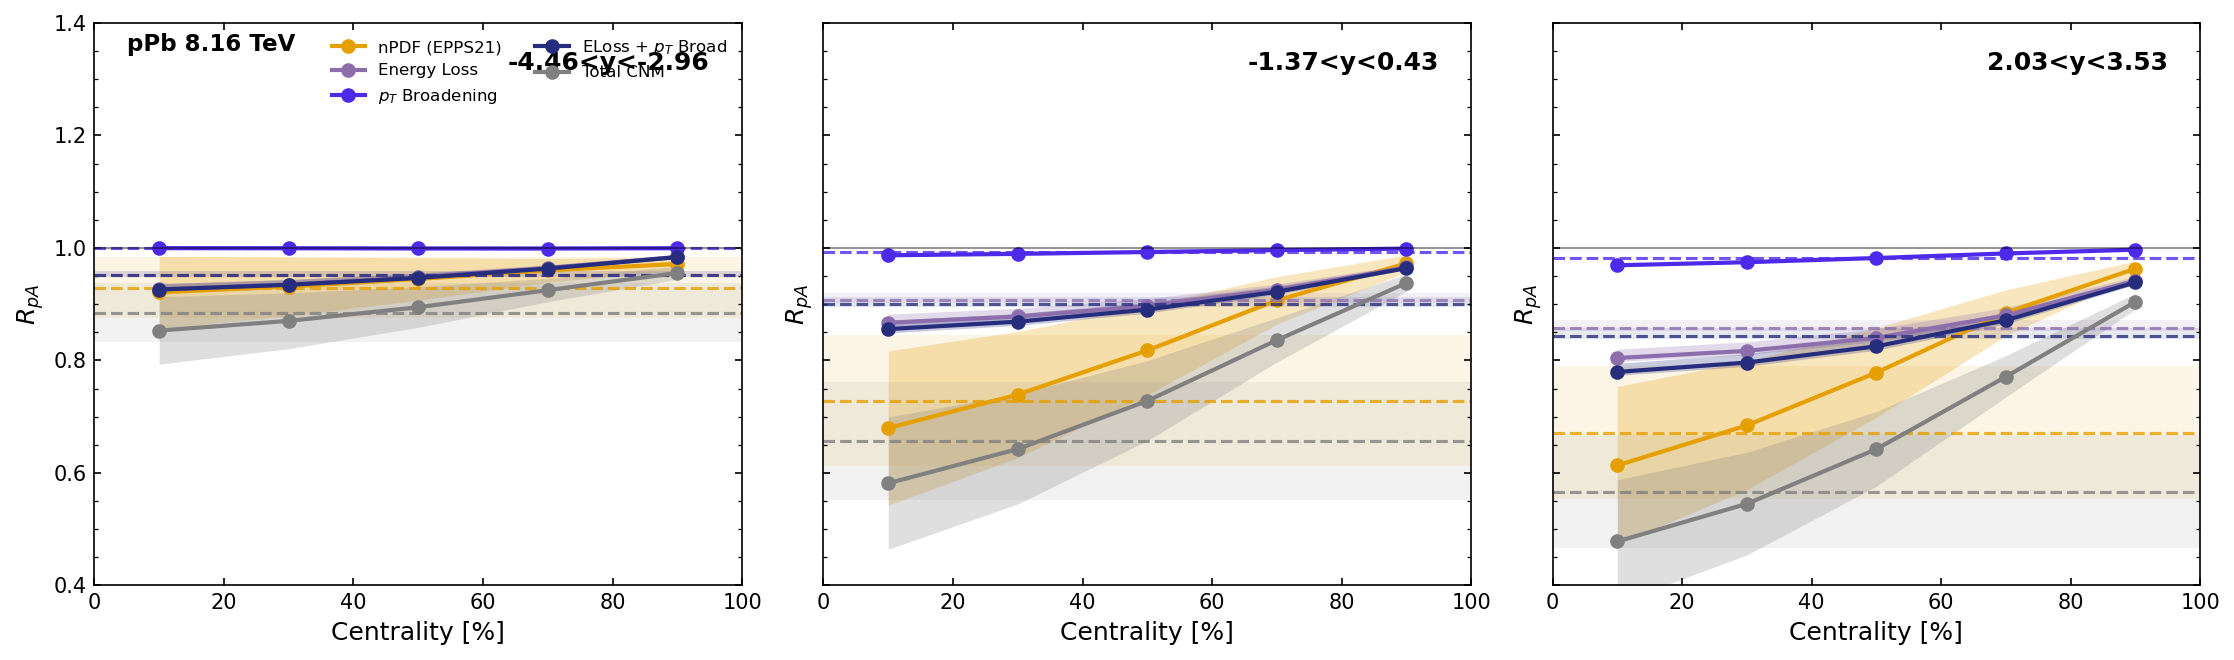

In [3]:
energies = [5.02, 8.16]
for energy in energies:
    print(f"\nProcessing {energy} TeV...")
    sqrts = energy * 1000.0
    outdir = Path(f'../outputs/LHC_{energy}TeV')
    outdir.mkdir(parents=True, exist_ok=True)
    
    # 1. Setup CNM Driver
    particle = Particle(family='charmonia', state='avg')
    cnm = CNMCombineFast.from_defaults(
        energy=str(energy),
        family='charmonia',
        particle_state='avg',
        alpha_s_mode='constant',
        alpha0=0.5,
        cent_bins=Config.cent_bins_plotting
    )
    
    components = ['npdf', 'eloss', 'broad', 'eloss_broad', 'cnm']
    
    # ==========================================================
    # 1. R_pA vs y (Integrated over pT [0, 10] GeV)
    # ==========================================================
    y_edges = np.linspace(-5.0, 5.0, 21)
    y_cent, labels, final_bands_y = cnm.cnm_vs_y(
        y_edges, 
        pt_range_avg=Config.pt_range_integrated, 
        components=components,
        include_mb=True
    )
    
    # Plotting vs y
    tags_to_plot = labels + ['MB']
    n_pan = len(tags_to_plot)
    n_cols = 3
    n_rows = int(np.ceil(n_pan / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), dpi=DPI, sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()
    
    note_y = f"p+Pb @{energy} TeV\n$p_T \in [0, 10]$ GeV"
    
    for i, tag in enumerate(tags_to_plot):
        ax = axes[i]
        for comp in components:
            plot_component_band(ax, y_cent, final_bands_y, comp, tag, step=STEP_DEFAULT)
        
        apply_pub_style(ax, (-5, 5), (0.0, 2.0), 'y', r'$R_{pA}$', tag=tag, note=note_y if i==0 else None)
        if i == 0: ax.legend(loc='lower left', fontsize=8, ncol=2, frameon=False)
        
    for k in range(n_pan, len(axes)): fig.delaxes(axes[k])
    fig.tight_layout()
    if SAVE_PDF: fig.savefig(outdir / f'RpA_vs_y_all_components_{energy}TeV.pdf', bbox_inches='tight')
    plt.show()
    
    # ==========================================================
    # 2. R_pA vs pT in Rapidity Windows
    # ==========================================================
    for y_window in Config.rapidity_windows:
        y0, y1 = y_window
        w_name = f"{y0}<y<{y1}"
        print(f"  Computing vs pT in window {w_name}")
        pT_edges = np.arange(0, 17.5, 2.5) # Using restricted range for better focus
        pT_cent, labels_pt, final_bands_pt = cnm.cnm_vs_pT(
            y_window, 
            pT_edges, 
            components=components, 
            include_mb=True
        )
        
        # Panel Plot per window
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), dpi=DPI, sharex=True, sharey=True)
        axes = np.atleast_1d(axes).ravel()
        note_pt = f"pPb {energy} TeV\n{w_name}"
        
        for i, tag in enumerate(tags_to_plot):
            ax = axes[i]
            for comp in components:
                plot_component_band(ax, pT_cent, final_bands_pt, comp, tag, step=STEP_DEFAULT)
            apply_pub_style(ax, (0, 15), (0.2, 1.8), '$p_T$ [GeV]', r'$R_{pA}$', tag=tag, note=note_pt if i==0 else None)
            
        for k in range(n_pan, len(axes)): fig.delaxes(axes[k])
        fig.tight_layout()
        safe_w = w_name.replace('<','').replace('>','').replace('/','_')
        if SAVE_PDF: fig.savefig(outdir / f'RpA_vs_pt_all_components_{safe_w}_{energy}TeV.pdf', bbox_inches='tight')
        plt.show()

    # ==========================================================
    # 3. R_pA vs Centrality (3 Rapidity Windows)
    # ==========================================================
    print("  Computing vs Centrality...")
    # centers of centrality bins
    c_cent = np.array([0.5*(a+b) for (a,b) in Config.cent_bins_plotting])
    c_err = np.array([0.5*(b-a) for (a,b) in Config.cent_bins_plotting])
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=DPI, sharey=True)
    
    for ax, y_window in zip(axes, Config.rapidity_windows):
        y0, y1 = y_window
        res_cent = cnm.cnm_vs_centrality((y0, y1), pt_range_avg=Config.pt_range_integrated)
        
        # res_cent[comp] -> (vals_c, vals_lo, vals_hi, mb_c, mb_lo, mb_hi)
        for comp in components:
            color = COLORS[comp]
            label = COMP_LABELS[comp]
            vc, vl, vh, mbc, mbl, mbh = res_cent[comp]
            
            # Solid for per-bin centrality
            # We use x-error bars for bin width
            ax.plot(c_cent, vc, marker='o', color=color, lw=2.0, label=label if ax==axes[0] else None)
            ax.fill_between(c_cent, vl, vh, color=color, alpha=ALPHA_BAND, lw=0)
            
            # Dashed line for MB
            ax.axhline(mbc, color=color, ls='--', lw=1.5, alpha=0.8)
            # Shaded region for MB uncertainty
            ax.fill_between([0, 100], mbl, mbh, color=color, alpha=0.1, lw=0)
            
        apply_pub_style(ax, (0, 100), (0.4, 1.4), 'Centrality [%]', r'$R_{pA}$', tag=f"{y0}<y<{y1}")
        if ax == axes[0]:
            ax.legend(loc='upper right', fontsize=8, frameon=False, ncol=2)
            ax.text(0.05, 0.95, f"pPb {energy} TeV", transform=ax.transAxes, fontsize=11, fontweight='bold')

    fig.tight_layout()
    if SAVE_PDF: fig.savefig(outdir / f'RpA_vs_centrality_all_components_{energy}TeV.pdf', bbox_inches='tight')
    plt.show()